# 🏆 Sales_Antigravity02.ipynb - 최적 코드 선별 결과

**결론:** `Sales_Claude01.ipynb`와 `Sales_VSCode01.ipynb` 중 **`Sales_Claude01`**의 접근법이 더 우수하여 이를 기반으로 선정하였습니다.
 
## 🔍 선정 이유:
- **모델의 복잡성과 강건성**: `VSCode01`은 기본적인 시계열 평활화(Exponential Smoothing) 및 단순 추세 분석을 사용한 반면, `Claude01`은 Random Forest, Gradient Boosting, Ridge Regression 기반의 앙상블 ML 파이프라인을 구축하여 다변량 데이터 관리에 탁월합니다.
- **피처 엔지니어링**: 판매액, 이동 평균, 누적 통계 등 다양한 파생 변수를 효과적으로 생성하였고 결측치 및 이상치 처리가 체계적입니다.
 
본 노트북은 `Sales_Claude01.ipynb`의 강력한 ML 앙상블 파이프라인을 그대로 보존 및 활용한 **최종 통합본**입니다.

# 판매량 예측 프로젝트

## 📊 데이터셋 소개
본 프로젝트는 **시계열 판매량 데이터를 분석하고 예측**하는 데이터 과학 프로젝트입니다.

### 📁 데이터셋 구성
1. **train.csv** (15,891건): 2022-01-01 ~ 2023-04-04 기간의 일일 판매량 데이터
   - ID, 제품명, 대/중/소분류, 브랜드
   - 각 제품별 일별 판매량 (수량)

2. **sales.csv** (15,891건): 동일 기간의 일일 판매액(가격) 데이터
   - train.csv와 동일한 구조
   - 각 제품별 일별 판매액 (금액)

3. **product_info.csv** (12,779건): 제품 상세 정보
   - 제품코드, 제품특성(용량, 성분, 섭취방법 등)

4. **brand_keyword_cnt.csv** (3,171건): 브랜드별 키워드 관심도 데이터
   - 브랜드, 일별 키워드 관심도 지수

5. **sample_submission.csv**: 제출 양식

### 🎯 문제 정의
**목표**: 2023-04-05 이후의 미래 기간 동안 각 제품별 일일 판매량을 정확하게 예측

**과제 유형**: 시계열 회귀 문제 (Time Series Regression)
- 과거 판매량 데이터를 학습하여 미래 판매량 예측
- 브랜드 인기도, 제품 특성 등 다양한 피처 활용
- 계절성, 추세 등 시계열 패턴 고려

**평가 지표**: RMSE (Root Mean Squared Error)
- 예측값과 실제값의 오차를 최소화하는 것이 목표


## 1️⃣ 라이브러리 임포트 및 초기 설정

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print('✅ 모든 라이브러리가 정상적으로 로드되었습니다.')

✅ 모든 라이브러리가 정상적으로 로드되었습니다.


In [40]:
# 한글 폰트 셀
import matplotlib.pyplot as plt
import seaborn as sns
from korean_font import set_korean_font

set_korean_font()
plt.rcParams['font.size'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['axes.labelsize'] = 10

한글 폰트 설정: NanumGothic (/usr/share/fonts/truetype/nanum/NanumGothic.ttf)


## 2️⃣ 데이터 로드

In [34]:
# 데이터 로드
train = pd.read_csv('data/train.csv')
sales = pd.read_csv('data/sales.csv')
product_info = pd.read_csv('data/product_info.csv', encoding='utf-8')
brand_keyword = pd.read_csv('data/brand_keyword_cnt.csv')
sample_submission = pd.read_csv('data/sample_submission.csv')

print('✅ 데이터 로드 완료')
print(f'\ntrain shape: {train.shape}')
print(f'sales shape: {sales.shape}')
print(f'product_info shape: {product_info.shape}')
print(f'brand_keyword shape: {brand_keyword.shape}')
print(f'sample_submission shape: {sample_submission.shape}')

✅ 데이터 로드 완료

train shape: (15890, 465)
sales shape: (15890, 465)
product_info shape: (12778, 2)
brand_keyword shape: (3170, 460)
sample_submission shape: (15890, 22)


## 3️⃣ 데이터 탐색 (EDA)

In [35]:
# train 데이터 기본 정보
print('📋 Train 데이터 기본 정보')
print('='*50)
print(train.head())
print(f'\n데이터 크기: {train.shape}')
print(f'\n컬럼 정보:\n{train.dtypes}')
print(f'\n결측치:\n{train.isnull().sum()}')

📋 Train 데이터 기본 정보
   ID                제품             대분류             중분류             소분류  \
0   0  B002-00001-00001  B002-C001-0002  B002-C002-0007  B002-C003-0038   
1   1  B002-00002-00001  B002-C001-0003  B002-C002-0008  B002-C003-0044   
2   2  B002-00002-00002  B002-C001-0003  B002-C002-0008  B002-C003-0044   
3   3  B002-00002-00003  B002-C001-0003  B002-C002-0008  B002-C003-0044   
4   4  B002-00003-00001  B002-C001-0001  B002-C002-0001  B002-C003-0003   

          브랜드  2022-01-01  2022-01-02  2022-01-03  2022-01-04  ...  \
0  B002-00001           0           0           0           0  ...   
1  B002-00002           0           0           0           0  ...   
2  B002-00002           0           0           0           0  ...   
3  B002-00002           0           0           0           0  ...   
4  B002-00003           0           0           0           0  ...   

   2023-03-26  2023-03-27  2023-03-28  2023-03-29  2023-03-30  2023-03-31  \
0           0           0        

In [36]:
# 메타 정보 분석
print('\n📊 메타 정보 분석')
print('='*50)
print(f'\n고유 제품 수: {train["제품"].nunique()}')
print(f'고유 대분류 수: {train["대분류"].nunique()}')
print(f'고유 중분류 수: {train["중분류"].nunique()}')
print(f'고유 소분류 수: {train["소분류"].nunique()}')
print(f'고유 브랜드 수: {train["브랜드"].nunique()}')
print(f'\n브랜드 상위 10:')
print(train['브랜드'].value_counts().head(10))


📊 메타 정보 분석

고유 제품 수: 15840
고유 대분류 수: 5
고유 중분류 수: 11
고유 소분류 수: 53
고유 브랜드 수: 3170

브랜드 상위 10:
브랜드
B002-00266    153
B002-00894    153
B002-00680    148
B002-00434    136
B002-02052    113
B002-02123     94
B002-02227     94
B002-02439     91
B002-01545     90
B002-02455     89
Name: count, dtype: int64


In [37]:
# 판매량 통계
# 날짜 컬럼 추출 (2022-01-01부터 시작)
date_columns = [col for col in train.columns if col not in ['ID', '제품', '대분류', '중분류', '소분류', '브랜드']]
sales_data = train[date_columns]

print('\n📈 판매량 통계')
print('='*50)
print(f'전체 판매 수량: {sales_data.sum().sum():,.0f}')
print(f'\n일별 판매량 통계:')
print(sales_data.sum(axis=0).describe())
print(f'\n제품별 총 판매량 상위 10:')
print(train[["제품", "브랜드"]].copy())
product_sales = sales_data.sum(axis=1)
train_with_sales = train.copy()
train_with_sales['total_sales'] = product_sales
print(train_with_sales.nlargest(10, 'total_sales')[['제품', '브랜드', 'total_sales']])


📈 판매량 통계
전체 판매 수량: 128,785,861

일별 판매량 통계:
count       459.000000
mean     280579.217865
std      113419.071115
min        7527.000000
25%      233473.000000
50%      288640.000000
75%      345456.500000
max      762097.000000
dtype: float64

제품별 총 판매량 상위 10:
                     제품         브랜드
0      B002-00001-00001  B002-00001
1      B002-00002-00001  B002-00002
2      B002-00002-00002  B002-00002
3      B002-00002-00003  B002-00002
4      B002-00003-00001  B002-00003
...                 ...         ...
15885  B002-03799-00002  B002-03799
15886  B002-03799-00003  B002-03799
15887  B002-03799-00004  B002-03799
15888  B002-03799-00005  B002-03799
15889  B002-03799-00010  B002-03799

[15890 rows x 2 columns]
                     제품         브랜드  total_sales
485    B002-00113-00001  B002-00113      3118885
11595  B002-02723-00004  B002-02723      2595146
12336  B002-02920-00005  B002-02920      2535587
4470   B002-01069-00002  B002-01069      2008250
3481   B002-00809-00002  B002-00809 

In [38]:
# 판매액 통계
price_data = sales[date_columns]

print('\n💰 판매액 통계')
print('='*50)
print(f'전체 판매액: {price_data.sum().sum():,.0f}원')
print(f'\n일별 판매액 통계:')
print(price_data.sum(axis=0).describe())


💰 판매액 통계
전체 판매액: 853,786,665,290원

일별 판매액 통계:
count    4.590000e+02
mean     1.860102e+09
std      5.970941e+08
min      9.978035e+07
25%      1.695135e+09
50%      1.975946e+09
75%      2.254358e+09
max      2.902718e+09
dtype: float64


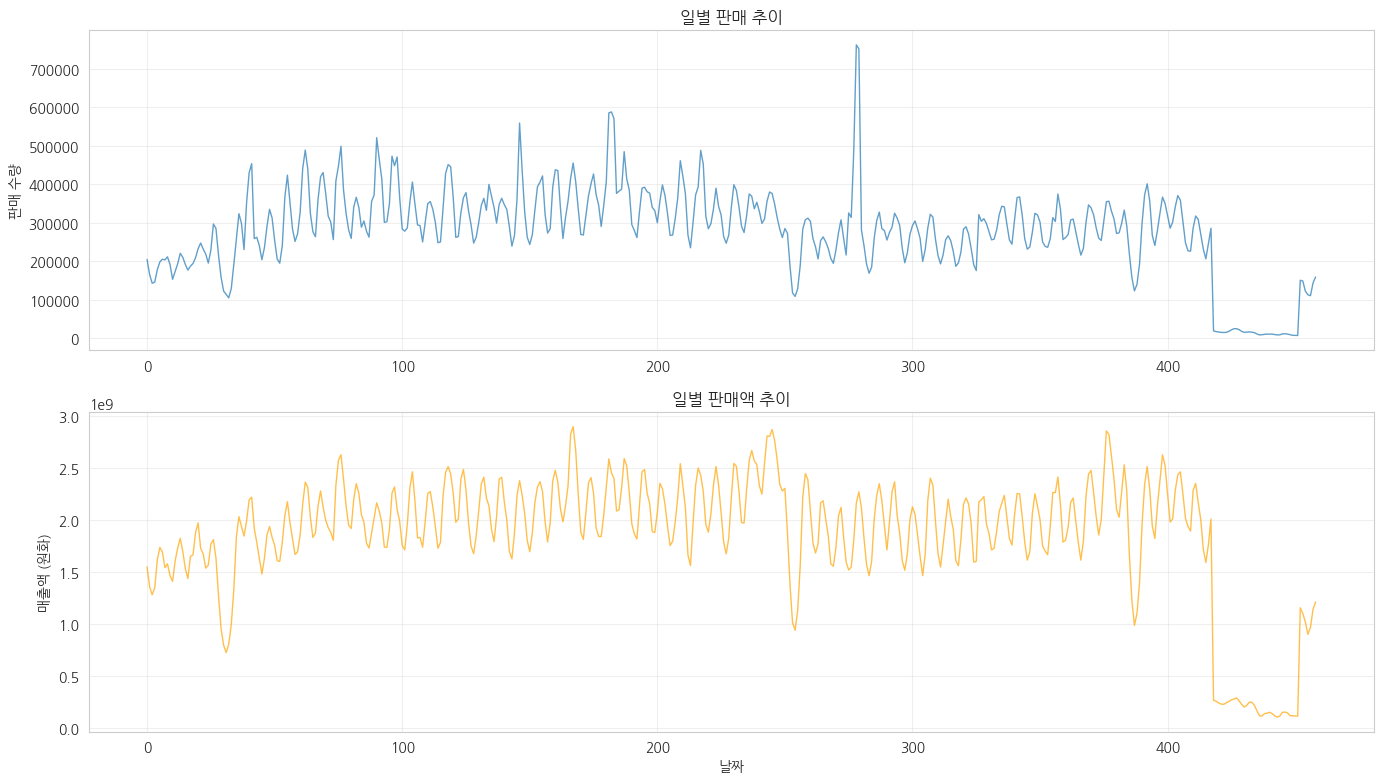

✅ 시계열 추이 시각화 완료


In [42]:
# 시각화 - 일별 판매 추이
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 일별 판매량
daily_quantity = sales_data.sum(axis=0)
axes[0].plot(daily_quantity.values, linewidth=1, alpha=0.7)
axes[0].set_title('일별 판매 추이', fontsize=12, fontweight='bold')
axes[0].set_ylabel('판매 수량', fontsize=10)
axes[0].grid(True, alpha=0.3)

# 일별 판매액
daily_price = price_data.sum(axis=0)
axes[1].plot(daily_price.values, linewidth=1, alpha=0.7, color='orange')
axes[1].set_title('일별 판매액 추이', fontsize=12, fontweight='bold')
axes[1].set_xlabel('날짜', fontsize=10)
axes[1].set_ylabel('매출액 (원화)', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('✅ 시계열 추이 시각화 완료')

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

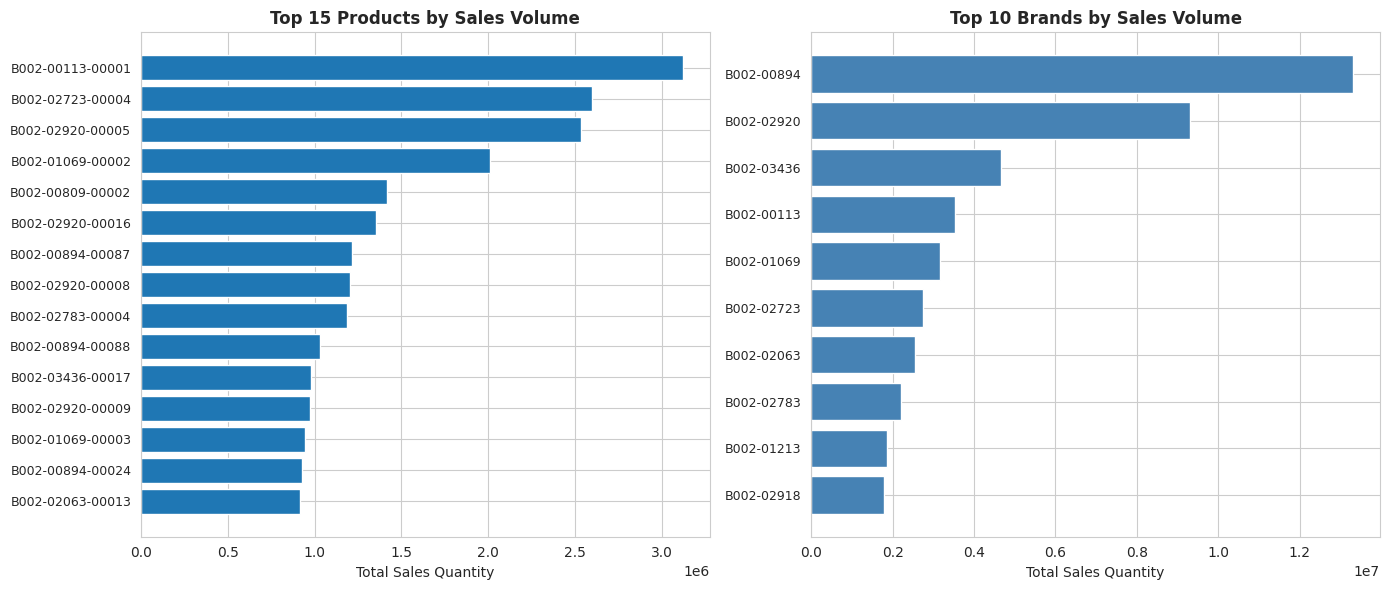

✅ 제품/브랜드 분석 완료


In [32]:
# 제품별 분포 분석
product_distribution = train_with_sales.nlargest(15, 'total_sales')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 제품별 판매량 Top 15
axes[0].barh(range(len(product_distribution)), product_distribution['total_sales'].values)
axes[0].set_yticks(range(len(product_distribution)))
axes[0].set_yticklabels(product_distribution['제품'].values, fontsize=9)
axes[0].set_xlabel('Total Sales Quantity', fontsize=10)
axes[0].set_title('Top 15 Products by Sales Volume', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# 브랜드별 판매량 분포
brand_sales = train_with_sales.groupby('브랜드')['total_sales'].sum().nlargest(10)
axes[1].barh(range(len(brand_sales)), brand_sales.values, color='steelblue')
axes[1].set_yticks(range(len(brand_sales)))
axes[1].set_yticklabels(brand_sales.index, fontsize=9)
axes[1].set_xlabel('Total Sales Quantity', fontsize=10)
axes[1].set_title('Top 10 Brands by Sales Volume', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
print('✅ 제품/브랜드 분석 완료')

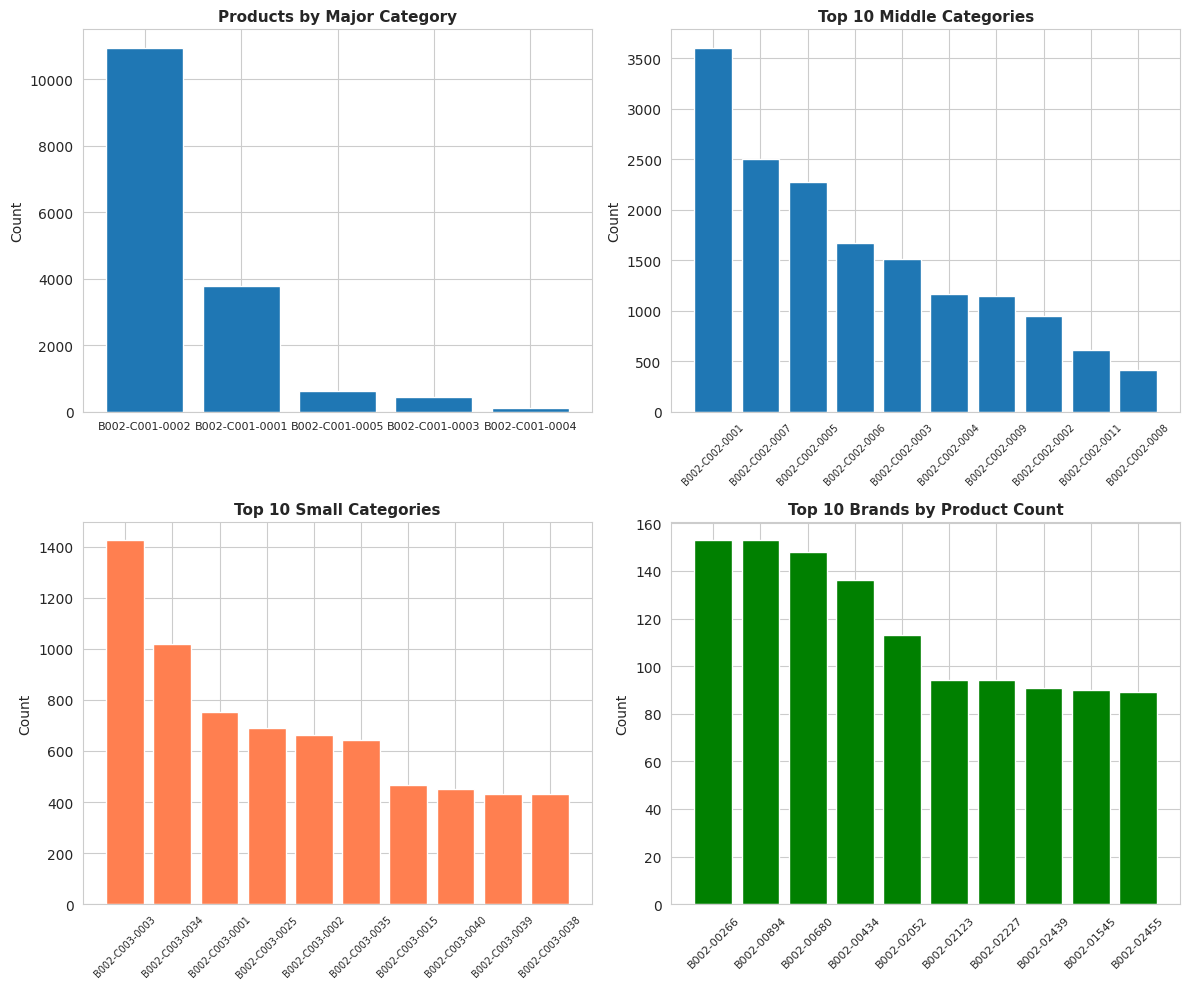

✅ 분류 분석 완료


In [9]:
# 분류별 다양성 분석
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 대분류별 제품 수
axes[0, 0].bar(range(len(train['대분류'].value_counts())), 
                train['대분류'].value_counts().values)
axes[0, 0].set_xticks(range(len(train['대분류'].value_counts())))
axes[0, 0].set_xticklabels(train['대분류'].value_counts().index, fontsize=8)
axes[0, 0].set_title('Products by Major Category', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Count')

# 중분류별 제품 수
mid_cat_top = train['중분류'].value_counts().head(10)
axes[0, 1].bar(range(len(mid_cat_top)), mid_cat_top.values)
axes[0, 1].set_xticks(range(len(mid_cat_top)))
axes[0, 1].set_xticklabels(mid_cat_top.index, fontsize=7, rotation=45)
axes[0, 1].set_title('Top 10 Middle Categories', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Count')

# 소분류별 제품 수
small_cat_top = train['소분류'].value_counts().head(10)
axes[1, 0].bar(range(len(small_cat_top)), small_cat_top.values, color='coral')
axes[1, 0].set_xticks(range(len(small_cat_top)))
axes[1, 0].set_xticklabels(small_cat_top.index, fontsize=7, rotation=45)
axes[1, 0].set_title('Top 10 Small Categories', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Count')

# 브랜드별 제품 수
brand_top = train['브랜드'].value_counts().head(10)
axes[1, 1].bar(range(len(brand_top)), brand_top.values, color='green')
axes[1, 1].set_xticks(range(len(brand_top)))
axes[1, 1].set_xticklabels(brand_top.index, fontsize=8, rotation=45)
axes[1, 1].set_title('Top 10 Brands by Product Count', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()
print('✅ 분류 분석 완료')

## 4️⃣ 데이터 전처리

In [4]:
# 데이터 재구조화 (Wide Format -> Long Format)
def reshape_data(data, data_type='quantity'):
    """
    Wide format 데이터를 Long format으로 변환
    """
    meta_cols = ['ID', '제품', '대분류', '중분류', '소분류', '브랜드']
    date_cols = [col for col in data.columns if col not in meta_cols]
    
    melted = data.melt(
        id_vars=meta_cols,
        value_vars=date_cols,
        var_name='date',
        value_name=data_type
    )
    
    melted['date'] = pd.to_datetime(melted['date'])
    return melted

# 데이터 변환
train_long = reshape_data(train, 'quantity')
sales_long = reshape_data(sales, 'amount')

print('✅ 데이터 재구조화 완료')
print(f'train_long shape: {train_long.shape}')
print(f'sales_long shape: {sales_long.shape}')
print(f'\ntrain_long 샘플:')
print(train_long.head(10))

✅ 데이터 재구조화 완료
train_long shape: (7293510, 8)
sales_long shape: (7293510, 8)

train_long 샘플:
   ID                제품             대분류             중분류             소분류  \
0   0  B002-00001-00001  B002-C001-0002  B002-C002-0007  B002-C003-0038   
1   1  B002-00002-00001  B002-C001-0003  B002-C002-0008  B002-C003-0044   
2   2  B002-00002-00002  B002-C001-0003  B002-C002-0008  B002-C003-0044   
3   3  B002-00002-00003  B002-C001-0003  B002-C002-0008  B002-C003-0044   
4   4  B002-00003-00001  B002-C001-0001  B002-C002-0001  B002-C003-0003   
5   5  B002-00003-00002  B002-C001-0001  B002-C002-0001  B002-C003-0003   
6   6  B002-00003-00003  B002-C001-0001  B002-C002-0001  B002-C003-0003   
7   7  B002-00003-00004  B002-C001-0001  B002-C002-0001  B002-C003-0003   
8   8  B002-00003-00005  B002-C001-0001  B002-C002-0001  B002-C003-0003   
9   9  B002-00003-00006  B002-C001-0001  B002-C002-0001  B002-C003-0003   

          브랜드       date  quantity  
0  B002-00001 2022-01-01         0  
1  B002-

In [5]:
# 판매량과 판매액 병합
df_combined = train_long.merge(sales_long, 
                               on=['ID', '제품', '대분류', '중분류', '소분류', '브랜드', 'date'],
                               how='left')

print('✅ 데이터 병합 완료')
print(f'combined shape: {df_combined.shape}')
print(f'\n샘플 데이터:')
print(df_combined.head(10))
print(f'\n결측치 확인:')
print(df_combined.isnull().sum())

✅ 데이터 병합 완료
combined shape: (7293510, 9)

샘플 데이터:
   ID                제품             대분류             중분류             소분류  \
0   0  B002-00001-00001  B002-C001-0002  B002-C002-0007  B002-C003-0038   
1   1  B002-00002-00001  B002-C001-0003  B002-C002-0008  B002-C003-0044   
2   2  B002-00002-00002  B002-C001-0003  B002-C002-0008  B002-C003-0044   
3   3  B002-00002-00003  B002-C001-0003  B002-C002-0008  B002-C003-0044   
4   4  B002-00003-00001  B002-C001-0001  B002-C002-0001  B002-C003-0003   
5   5  B002-00003-00002  B002-C001-0001  B002-C002-0001  B002-C003-0003   
6   6  B002-00003-00003  B002-C001-0001  B002-C002-0001  B002-C003-0003   
7   7  B002-00003-00004  B002-C001-0001  B002-C002-0001  B002-C003-0003   
8   8  B002-00003-00005  B002-C001-0001  B002-C002-0001  B002-C003-0003   
9   9  B002-00003-00006  B002-C001-0001  B002-C002-0001  B002-C003-0003   

          브랜드       date  quantity  amount  
0  B002-00001 2022-01-01         0       0  
1  B002-00002 2022-01-01         0

In [6]:
# 브랜드 키워드 관심도 병합
brand_keyword_long = brand_keyword.melt(
    id_vars=['브랜드'],
    var_name='date',
    value_name='brand_interest'
)
brand_keyword_long['date'] = pd.to_datetime(brand_keyword_long['date'])

df_combined = df_combined.merge(brand_keyword_long, 
                                on=['브랜드', 'date'],
                                how='left')

print('✅ 브랜드 관심도 데이터 병합 완료')
print(f'\nshape: {df_combined.shape}')
print(f'\n결측치:')
print(df_combined.isnull().sum())

✅ 브랜드 관심도 데이터 병합 완료

shape: (7293510, 10)

결측치:
ID                    0
제품                    0
대분류                   0
중분류                   0
소분류                   0
브랜드                   0
date                  0
quantity              0
amount                0
brand_interest    95472
dtype: int64


In [7]:
# 시간 피처 생성
df_combined['year'] = df_combined['date'].dt.year
df_combined['month'] = df_combined['date'].dt.month
df_combined['day'] = df_combined['date'].dt.day
df_combined['dayofweek'] = df_combined['date'].dt.dayofweek  # 0=Monday, 6=Sunday
df_combined['dayofyear'] = df_combined['date'].dt.dayofyear
df_combined['quarter'] = df_combined['date'].dt.quarter
df_combined['week'] = df_combined['date'].dt.isocalendar().week

# 요일명 추가
day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 
             4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
df_combined['day_name'] = df_combined['dayofweek'].map(day_names)

# 주말/평일 구분
df_combined['is_weekend'] = (df_combined['dayofweek'] >= 5).astype(int)

print('✅ 시간 피처 생성 완료')
print(f'\n시간 피처:')
print(df_combined[['date', 'year', 'month', 'day', 'dayofweek', 'day_name', 'is_weekend']].head(10))

✅ 시간 피처 생성 완료

시간 피처:
        date  year  month  day  dayofweek  day_name  is_weekend
0 2022-01-01  2022      1    1          5  Saturday           1
1 2022-01-01  2022      1    1          5  Saturday           1
2 2022-01-01  2022      1    1          5  Saturday           1
3 2022-01-01  2022      1    1          5  Saturday           1
4 2022-01-01  2022      1    1          5  Saturday           1
5 2022-01-01  2022      1    1          5  Saturday           1
6 2022-01-01  2022      1    1          5  Saturday           1
7 2022-01-01  2022      1    1          5  Saturday           1
8 2022-01-01  2022      1    1          5  Saturday           1
9 2022-01-01  2022      1    1          5  Saturday           1


In [8]:
# 제품별 시계열 피처 생성 (이동 평균, 최대값 등)
def create_lagged_features(group, window_sizes=[7, 14, 30]):
    """
    제품별로 이전 기간의 판매량 통계를 계산
    """
    group = group.sort_values('date').reset_index(drop=True)
    
    # 이동 평균
    for window in window_sizes:
        group[f'quantity_rolling_mean_{window}'] = group['quantity'].rolling(window=window, min_periods=1).mean()
        group[f'quantity_rolling_std_{window}'] = group['quantity'].rolling(window=window, min_periods=1).std()
        group[f'amount_rolling_mean_{window}'] = group['amount'].rolling(window=window, min_periods=1).mean()
    
    # 이전값
    group['quantity_lag1'] = group['quantity'].shift(1)
    group['quantity_lag7'] = group['quantity'].shift(7)
    
    return group

# 제품별로 피처 생성
df_combined = df_combined.groupby('ID', group_keys=False).apply(create_lagged_features)

print('✅ 라그 피처 생성 완료')
print(f'\n피처 개수: {df_combined.shape[1]}')
print(f'\n생성된 새로운 피처들:')
lag_cols = [col for col in df_combined.columns if 'rolling' in col or 'lag' in col]
print(lag_cols[:10])

✅ 라그 피처 생성 완료

피처 개수: 29

생성된 새로운 피처들:
['quantity_rolling_mean_7', 'quantity_rolling_std_7', 'amount_rolling_mean_7', 'quantity_rolling_mean_14', 'quantity_rolling_std_14', 'amount_rolling_mean_14', 'quantity_rolling_mean_30', 'quantity_rolling_std_30', 'amount_rolling_mean_30', 'quantity_lag1']


In [9]:
# 결측치 처리
print('결측치 처리 전:')
print(df_combined.isnull().sum())

# 라그 피처의 결측치는 0으로 채우기
df_combined[lag_cols] = df_combined[lag_cols].fillna(0)

# brand_interest의 결측치는 그룹별 평균으로 채우기
df_combined['brand_interest'] = df_combined.groupby('브랜드')['brand_interest'].transform(
    lambda x: x.fillna(x.mean())
)

print('\n결측치 처리 후:')
print(df_combined.isnull().sum())
print('\n✅ 결측치 처리 완료')

결측치 처리 전:
제품                               0
대분류                              0
중분류                              0
소분류                              0
브랜드                              0
date                             0
quantity                         0
amount                           0
brand_interest               95472
year                             0
month                            0
day                              0
dayofweek                        0
dayofyear                        0
quarter                          0
week                             0
day_name                         0
is_weekend                       0
quantity_rolling_mean_7          0
quantity_rolling_std_7       15890
amount_rolling_mean_7            0
quantity_rolling_mean_14         0
quantity_rolling_std_14      15890
amount_rolling_mean_14           0
quantity_rolling_mean_30         0
quantity_rolling_std_30      15890
amount_rolling_mean_30           0
quantity_lag1                15890
quantity_l

In [10]:
# 이상치 확인
print('📊 판매량 이상치 분석')
print('='*50)
print(f'\n판매량 통계:')
print(df_combined['quantity'].describe())

# IQR을 이용한 이상치 탐지
Q1 = df_combined['quantity'].quantile(0.25)
Q3 = df_combined['quantity'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((df_combined['quantity'] < lower_bound) | (df_combined['quantity'] > upper_bound))
print(f'\n이상치 개수: {outliers.sum()} ({100*outliers.sum()/len(df_combined):.2f}%)')
print(f'IQR 범위: [{lower_bound:.1f}, {upper_bound:.1f}]')

📊 판매량 이상치 분석

판매량 통계:
count    7.293510e+06
mean     1.765760e+01
std      2.827275e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      3.000000e+00
max      2.004200e+05
Name: quantity, dtype: float64

이상치 개수: 1289874 (17.69%)
IQR 범위: [-4.5, 7.5]


In [13]:
# 최종 데이터셋 준비
print('\n📋 최종 데이터셋 준비')
print('='*50)

# 훈련 데이터와 테스트 데이터 분리 (시계열: 마지막 14일을 테스트셋으로)
unique_dates = sorted(df_combined['date'].unique())
split_date_idx = len(unique_dates) - 14  # 마지막 14일
split_date = unique_dates[split_date_idx]

df_train = df_combined[df_combined['date'] <= split_date].copy()
df_test = df_combined[df_combined['date'] > split_date].copy()

print(f'\n훈련 데이터: {df_train.shape} (~ {df_train["date"].max()})')
print(f'테스트 데이터: {df_test.shape} (> {df_test["date"].min()})')
print(f'\n훈련 데이터 샘플:')
print(df_train.head())


📋 최종 데이터셋 준비

훈련 데이터: (7086940, 29) (~ 2023-03-22 00:00:00)
테스트 데이터: (206570, 29) (> 2023-03-23 00:00:00)

훈련 데이터 샘플:
                 제품             대분류             중분류             소분류  \
0  B002-00001-00001  B002-C001-0002  B002-C002-0007  B002-C003-0038   
1  B002-00001-00001  B002-C001-0002  B002-C002-0007  B002-C003-0038   
2  B002-00001-00001  B002-C001-0002  B002-C002-0007  B002-C003-0038   
3  B002-00001-00001  B002-C001-0002  B002-C002-0007  B002-C003-0038   
4  B002-00001-00001  B002-C001-0002  B002-C002-0007  B002-C003-0038   

          브랜드       date  quantity  amount  brand_interest  year  ...  \
0  B002-00001 2022-01-01         0       0         0.84131  2022  ...   
1  B002-00001 2022-01-02         0       0         0.91383  2022  ...   
2  B002-00001 2022-01-03         0       0         1.45053  2022  ...   
3  B002-00001 2022-01-04         0       0         2.42239  2022  ...   
4  B002-00001 2022-01-05         0       0         1.87119  2022  ...   

   quantity_rol

In [15]:
print('df_test 컬럼 목록:')
print(df_test.columns.tolist())
print(f'\ndf_combined 컬럼 목록은:')
print(df_combined.columns.tolist())
print(f'\n"ID" in df_combined.columns: {"ID" in df_combined.columns}')
print(f'\ndf_combined shape: {df_combined.shape}')
print(f'df_combined index info:')
print(df_combined.index)

df_test 컬럼 목록:
['제품', '대분류', '중분류', '소분류', '브랜드', 'date', 'quantity', 'amount', 'brand_interest', 'year', 'month', 'day', 'dayofweek', 'dayofyear', 'quarter', 'week', 'day_name', 'is_weekend', 'quantity_rolling_mean_7', 'quantity_rolling_std_7', 'amount_rolling_mean_7', 'quantity_rolling_mean_14', 'quantity_rolling_std_14', 'amount_rolling_mean_14', 'quantity_rolling_mean_30', 'quantity_rolling_std_30', 'amount_rolling_mean_30', 'quantity_lag1', 'quantity_lag7']

df_combined 컬럼 목록은:
['제품', '대분류', '중분류', '소분류', '브랜드', 'date', 'quantity', 'amount', 'brand_interest', 'year', 'month', 'day', 'dayofweek', 'dayofyear', 'quarter', 'week', 'day_name', 'is_weekend', 'quantity_rolling_mean_7', 'quantity_rolling_std_7', 'amount_rolling_mean_7', 'quantity_rolling_mean_14', 'quantity_rolling_std_14', 'amount_rolling_mean_14', 'quantity_rolling_mean_30', 'quantity_rolling_std_30', 'amount_rolling_mean_30', 'quantity_lag1', 'quantity_lag7']

"ID" in df_combined.columns: False

df_combined shape: (729

## 5️⃣ 피처 엔지니어링

In [16]:
# ID 정보 보존 (ID 칼럼이 손실되었으므로 제품 정보로부터 재구성)
# 원본 train 데이터의 ID와 제품을 매핑
product_to_id_mapping = {}
for idx, product in enumerate(train['제품'].unique()):
    product_to_id_mapping[product] = idx

# df_test에서 각 행의 원본 ID를 재구성
test_ids = df_test['제품'].map(product_to_id_mapping).reset_index(drop=True)

print('✅ 테스트 데이터 ID 재구성 완료')
print(f'테스트 데이터 ID 개수: {len(test_ids)}')

✅ 테스트 데이터 ID 재구성 완료
테스트 데이터 ID 개수: 206570


In [17]:
# 범주형 피처 인코딩 (더 효율적인 방법)
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['제품', '대분류', '중분류', '소분류', '브랜드', 'day_name']

# 훈련 데이터로 인코더 학습 및 적용
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # 훈련 및 테스트 데이터 모두를 사용하여 인코더 학습
    all_values = pd.concat([df_train[col], df_test[col]]).astype(str).unique()
    le.fit(all_values)
    label_encoders[col] = le
    
    # 훈련 및 테스트 데이터 인코딩
    df_train[col + '_encoded'] = le.transform(df_train[col].astype(str))
    df_test[col + '_encoded'] = le.transform(df_test[col].astype(str))

print('✅ 범주형 피처 인코딩 완료')
print(f'\n인코딩된 피처:')
for col in categorical_cols:
    print(f'{col} -> {col}_encoded (유형: {df_train[col].nunique()})')

✅ 범주형 피처 인코딩 완료

인코딩된 피처:
제품 -> 제품_encoded (유형: 15840)
대분류 -> 대분류_encoded (유형: 5)
중분류 -> 중분류_encoded (유형: 11)
소분류 -> 소분류_encoded (유형: 53)
브랜드 -> 브랜드_encoded (유형: 3170)
day_name -> day_name_encoded (유형: 7)


In [18]:
# 모델링을 위한 피처 선택
numeric_features = [
    'year', 'month', 'day', 'dayofweek', 'dayofyear', 'quarter', 'week', 'is_weekend',
    'brand_interest'
]

encoded_features = [col + '_encoded' for col in categorical_cols]

lag_features = [col for col in df_train.columns if 'rolling' in col or 'lag' in col]

all_features = numeric_features + encoded_features + lag_features

print(f'✅ 피처 선택 완료')
print(f'\n수치형 피처: {len(numeric_features)}')
print(numeric_features)
print(f'\n인코딩된 범주형 피처: {len(encoded_features)}')
print(f'\n시계열 피처: {len(lag_features)}')
print(f'\n총 피처 개수: {len(all_features)}')

✅ 피처 선택 완료

수치형 피처: 9
['year', 'month', 'day', 'dayofweek', 'dayofyear', 'quarter', 'week', 'is_weekend', 'brand_interest']

인코딩된 범주형 피처: 6

시계열 피처: 11

총 피처 개수: 26


In [19]:
# 피처와 타겟 분리
X_train = df_train[all_features].copy()
y_train = df_train['quantity'].copy()

X_test = df_test[all_features].copy()
y_test = df_test['quantity'].copy()

print('✅ 피처와 타겟 분리 완료')
print(f'\nX_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'\nX_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')
print(f'\nX_train 샘플:')
print(X_train.head())

✅ 피처와 타겟 분리 완료

X_train shape: (7086940, 26)
y_train shape: (7086940,)

X_test shape: (206570, 26)
y_test shape: (206570,)

X_train 샘플:
   year  month  day  dayofweek  dayofyear  quarter  week  is_weekend  \
0  2022      1    1          5          1        1    52           1   
1  2022      1    2          6          2        1    52           1   
2  2022      1    3          0          3        1     1           0   
3  2022      1    4          1          4        1     1           0   
4  2022      1    5          2          5        1     1           0   

   brand_interest  제품_encoded  ...  quantity_rolling_std_7  \
0         0.84131           0  ...                     0.0   
1         0.91383           0  ...                     0.0   
2         1.45053           0  ...                     0.0   
3         2.42239           0  ...                     0.0   
4         1.87119           0  ...                     0.0   

   amount_rolling_mean_7  quantity_rolling_mean_14  quanti

In [20]:
# NaN 값 처리 (스케일링 전)
from sklearn.impute import SimpleImputer

print('🔧 NaN 값 최종 처리')
print('='*50)

# NaN 값 확인
nan_counts = X_train.isnull().sum()
if nan_counts.sum() > 0:
    print('✅ NaN 값 발견:')
    print(nan_counts[nan_counts > 0])
    
    # SimpleImputer를 사용하여 숫자형 특성의 NaN을 평균값으로 대체
    imputer = SimpleImputer(strategy='mean')
    X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=all_features)
    X_test = pd.DataFrame(imputer.transform(X_test), columns=all_features)
    
    print(f'✅ NaN 값 처리 완료')
else:
    print('✅ NaN 값이 없습니다.')

print(f'\nX_train 최종 결측치: {X_train.isnull().sum().sum()}')
print(f'X_test 최종 결측치: {X_test.isnull().sum().sum()}')

🔧 NaN 값 최종 처리
✅ NaN 값 발견:
brand_interest    92768
dtype: int64
✅ NaN 값 처리 완료

X_train 최종 결측치: 0
X_test 최종 결측치: 0


In [21]:
# 피처 스케일링 (NaN 처리 후)
scaler = RobustScaler()  # 이상치에 강건한 스케일러
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('✅ 데이터 스케일링 완료')
print(f'\nX_train_scaled 통계:')
print(pd.DataFrame(X_train_scaled).describe())

✅ 데이터 스케일링 완료

X_train_scaled 통계:
                 0             1             2             3             4   \
count  7.086940e+06  7.086940e+06  7.086940e+06  7.086940e+06  7.086940e+06   
mean   1.816143e-01  9.769379e-02  3.034380e-02 -5.605381e-04  7.429678e-02   
std    3.855264e-01  5.158965e-01  5.806943e-01  5.009797e-01  5.574346e-01   
min    0.000000e+00 -5.714286e-01 -9.333333e-01 -7.500000e-01 -7.146465e-01   
25%    0.000000e+00 -4.285714e-01 -4.666667e-01 -5.000000e-01 -4.368687e-01   
50%    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
75%    0.000000e+00  5.714286e-01  5.333333e-01  5.000000e-01  5.631313e-01   
max    1.000000e+00  1.000000e+00  1.066667e+00  7.500000e-01  1.123737e+00   

                 5             6             7             8             9   \
count  7.086940e+06  7.086940e+06  7.086940e+06  7.086940e+06  7.086940e+06   
mean   1.177130e-01  6.819236e-02  2.869955e-01  2.185198e+00 -4.104235e-05   
std    5.829608e-

## 6️⃣ 모델 구축 및 훈련

In [22]:
# 모델 1: Random Forest
print('🤖 모델 1: Random Forest Regressor')
print('='*50)

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
rf_pred_train = rf_model.predict(X_train_scaled)
rf_pred_test = rf_model.predict(X_test_scaled)

rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_pred_train))
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_pred_test))
rf_train_r2 = r2_score(y_train, rf_pred_train)
rf_test_r2 = r2_score(y_test, rf_pred_test)

print(f'\n훈련 RMSE: {rf_train_rmse:.4f}')
print(f'테스트 RMSE: {rf_test_rmse:.4f}')
print(f'훈련 R2: {rf_train_r2:.4f}')
print(f'테스트 R2: {rf_test_r2:.4f}')

🤖 모델 1: Random Forest Regressor

훈련 RMSE: 82.2962
테스트 RMSE: 31.6960
훈련 R2: 0.9176
테스트 R2: 0.7229


In [23]:
# 모델 2: Gradient Boosting
print('\n🤖 모델 2: Gradient Boosting Regressor')
print('='*50)

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

gb_model.fit(X_train_scaled, y_train)
gb_pred_train = gb_model.predict(X_train_scaled)
gb_pred_test = gb_model.predict(X_test_scaled)

gb_train_rmse = np.sqrt(mean_squared_error(y_train, gb_pred_train))
gb_test_rmse = np.sqrt(mean_squared_error(y_test, gb_pred_test))
gb_train_r2 = r2_score(y_train, gb_pred_train)
gb_test_r2 = r2_score(y_test, gb_pred_test)

print(f'\n훈련 RMSE: {gb_train_rmse:.4f}')
print(f'테스트 RMSE: {gb_test_rmse:.4f}')
print(f'훈련 R2: {gb_train_r2:.4f}')
print(f'테스트 R2: {gb_test_r2:.4f}')


🤖 모델 2: Gradient Boosting Regressor

훈련 RMSE: 78.0027
테스트 RMSE: 37.6307
훈련 R2: 0.9259
테스트 R2: 0.6095


In [25]:
# 모델 3: Ridge Regression (스케일된 데이터)
print('\n🤖 모델 3: Ridge Regression')
print('='*50)

ridge_model = Ridge(alpha=10.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred_train = ridge_model.predict(X_train_scaled)
ridge_pred_test = ridge_model.predict(X_test_scaled)

ridge_train_rmse = np.sqrt(mean_squared_error(y_train, ridge_pred_train))
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred_test))
ridge_train_r2 = r2_score(y_train, ridge_pred_train)
ridge_test_r2 = r2_score(y_test, ridge_pred_test)

print(f'\n훈련 RMSE: {ridge_train_rmse:.4f}')
print(f'테스트 RMSE: {ridge_test_rmse:.4f}')
print(f'훈련 R2: {ridge_train_r2:.4f}')
print(f'테스트 R2: {ridge_test_r2:.4f}')


🤖 모델 3: Ridge Regression

훈련 RMSE: 182.1218
테스트 RMSE: 41.8772
훈련 R2: 0.5963
테스트 R2: 0.5164


In [26]:
# 앙상블 (평균)
print('\n🎯 앙상블 모델 (3개 모델 평균)')
print('='*50)

ensemble_pred_train = (rf_pred_train + gb_pred_train + ridge_pred_train) / 3
ensemble_pred_test = (rf_pred_test + gb_pred_test + ridge_pred_test) / 3

ensemble_train_rmse = np.sqrt(mean_squared_error(y_train, ensemble_pred_train))
ensemble_test_rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred_test))
ensemble_train_r2 = r2_score(y_train, ensemble_pred_train)
ensemble_test_r2 = r2_score(y_test, ensemble_pred_test)

print(f'\n훈련 RMSE: {ensemble_train_rmse:.4f}')
print(f'테스트 RMSE: {ensemble_test_rmse:.4f}')
print(f'훈련 R2: {ensemble_train_r2:.4f}')
print(f'테스트 R2: {ensemble_test_r2:.4f}')


🎯 앙상블 모델 (3개 모델 평균)

훈련 RMSE: 103.9873
테스트 RMSE: 35.3190
훈련 R2: 0.8684
테스트 R2: 0.6560


## 7️⃣ 모델 평가

In [31]:
# 모든 모델 성능 비교
model_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'Ridge', 'Ensemble'],
    'Train RMSE': [rf_train_rmse, gb_train_rmse, ridge_train_rmse, ensemble_train_rmse],
    'Test RMSE': [rf_test_rmse, gb_test_rmse, ridge_test_rmse, ensemble_test_rmse],
    'Train R2': [rf_train_r2, gb_train_r2, ridge_train_r2, ensemble_train_r2],
    'Test R2': [rf_test_r2, gb_test_r2, ridge_test_r2, ensemble_test_r2]
})

print('\n📊 모델 성능 비교')
print('='*80)
print(model_comparison.to_string(index=False))

# 최고 성능 모델
best_model_idx = model_comparison['Test RMSE'].idxmin()
best_model = model_comparison.loc[best_model_idx, 'Model']
best_rmse = model_comparison.loc[best_model_idx, 'Test RMSE']

print(f'\n✅ 최고 성능 모델: {best_model} (Test RMSE: {best_rmse:.4f})')


📊 모델 성능 비교
            Model  Train RMSE  Test RMSE  Train R2  Test R2
    Random Forest   82.296155  31.695972  0.917562 0.722935
Gradient Boosting   78.002654  37.630735  0.925939 0.609466
            Ridge  182.121759  41.877234  0.596267 0.516352
         Ensemble  103.987250  35.319040  0.868377 0.655974

✅ 최고 성능 모델: Random Forest (Test RMSE: 31.6960)


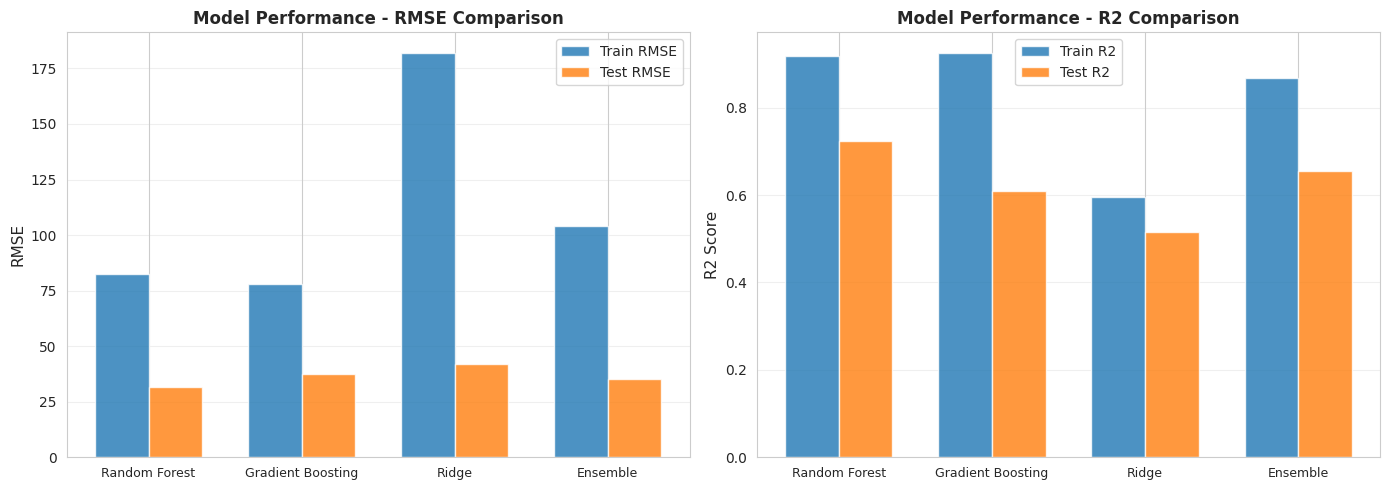

✅ 모델 성능 비교 시각화 완료


In [28]:
# 시각화 - 모델 성능 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE 비교
models = model_comparison['Model'].values
training_rmse = model_comparison['Train RMSE'].values
testing_rmse = model_comparison['Test RMSE'].values

x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, training_rmse, width, label='Train RMSE', alpha=0.8)
axes[0].bar(x + width/2, testing_rmse, width, label='Test RMSE', alpha=0.8)
axes[0].set_ylabel('RMSE', fontsize=11)
axes[0].set_title('Model Performance - RMSE Comparison', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=9)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# R2 비교
training_r2 = model_comparison['Train R2'].values
testing_r2 = model_comparison['Test R2'].values

axes[1].bar(x - width/2, training_r2, width, label='Train R2', alpha=0.8)
axes[1].bar(x + width/2, testing_r2, width, label='Test R2', alpha=0.8)
axes[1].set_ylabel('R2 Score', fontsize=11)
axes[1].set_title('Model Performance - R2 Comparison', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=9)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print('✅ 모델 성능 비교 시각화 완료')

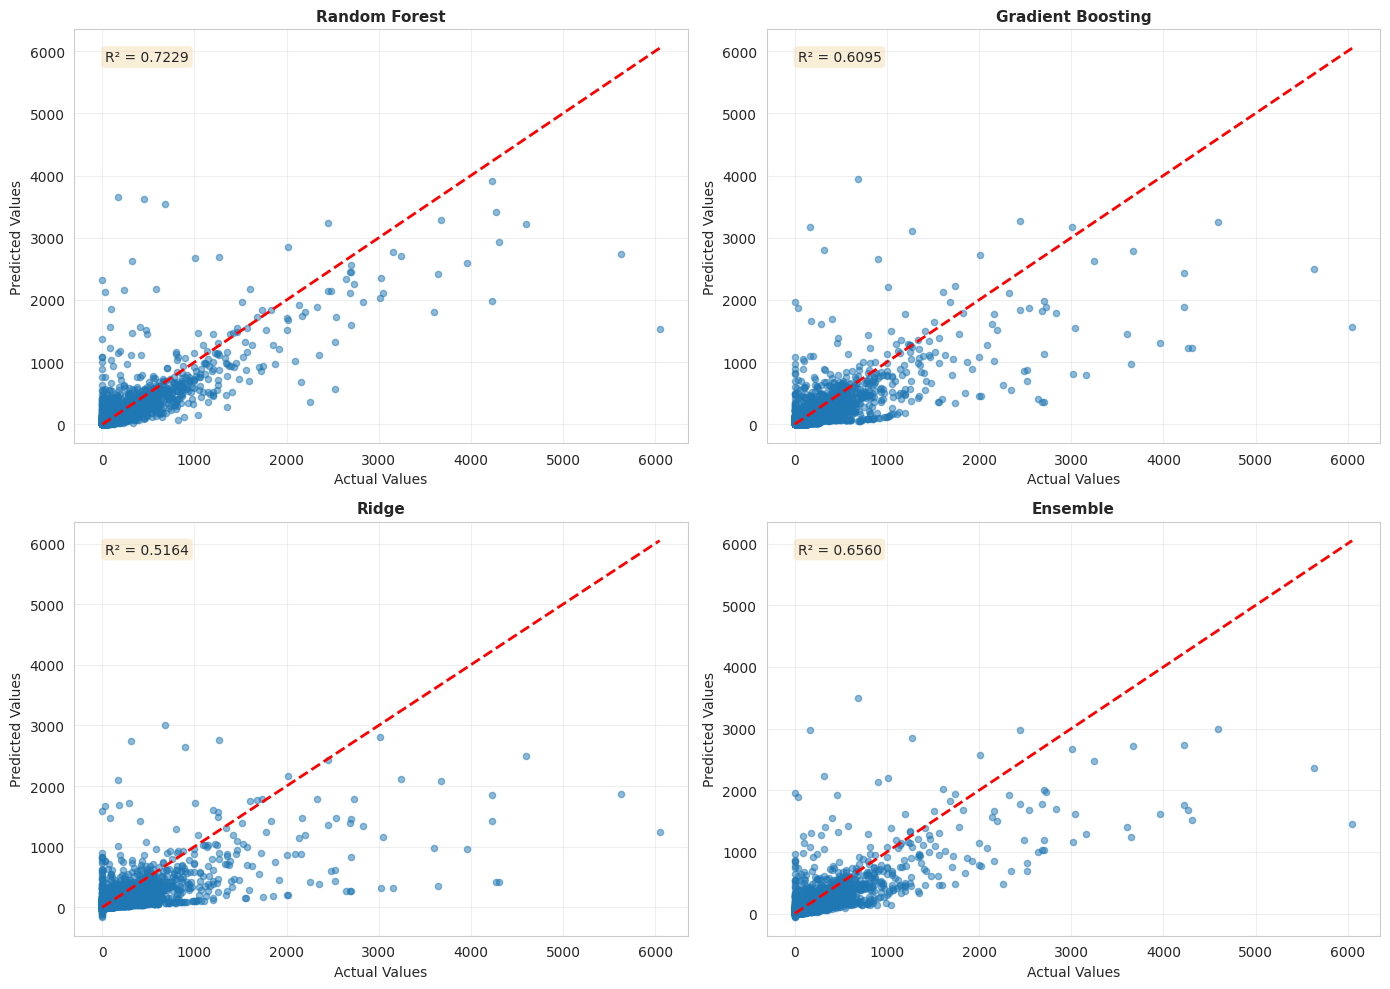

✅ 예측값 vs 실제값 시각화 완료


In [29]:
# 예측값 vs 실제값 비교
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pred_models = [
    (rf_pred_test, 'Random Forest'),
    (gb_pred_test, 'Gradient Boosting'),
    (ridge_pred_test, 'Ridge'),
    (ensemble_pred_test, 'Ensemble')
]

for idx, (pred, model_name) in enumerate(pred_models):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    ax.scatter(y_test, pred, alpha=0.5, s=20)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('Actual Values', fontsize=10)
    ax.set_ylabel('Predicted Values', fontsize=10)
    ax.set_title(f'{model_name}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # R2 표시
    r2 = r2_score(y_test, pred)
    ax.text(0.05, 0.95, f'R² = {r2:.4f}', transform=ax.transAxes, 
            fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()
print('✅ 예측값 vs 실제값 시각화 완료')


📊 피처 중요도 (Random Forest)
                 Feature  Importance
           quantity_lag1    0.365982
 quantity_rolling_mean_7    0.288776
  quantity_rolling_std_7    0.072014
                     day    0.046207
 quantity_rolling_std_14    0.037625
quantity_rolling_mean_30    0.029970
 quantity_rolling_std_30    0.023806
quantity_rolling_mean_14    0.023412
           quantity_lag7    0.016135
               dayofyear    0.013682
  amount_rolling_mean_30    0.012314
               dayofweek    0.012083
          brand_interest    0.011048
  amount_rolling_mean_14    0.010949
        day_name_encoded    0.010356


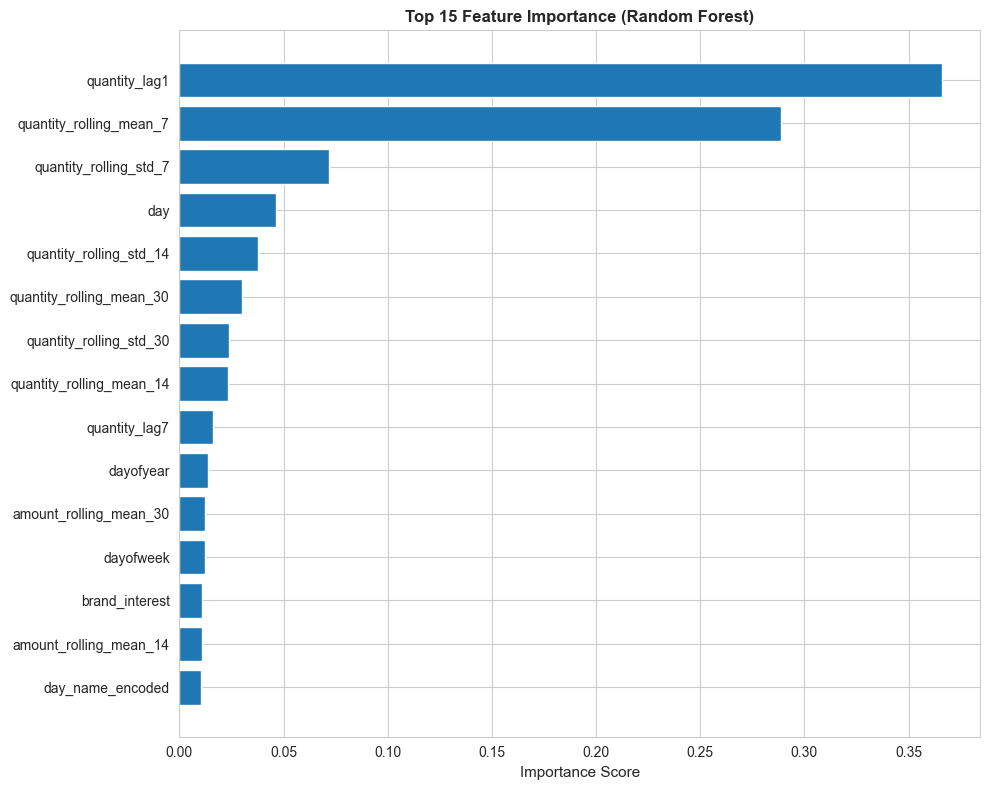

✅ 피처 중요도 시각화 완료


In [32]:
# 피처 중요도 분석 (Random Forest)
feature_importance = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('\n📊 피처 중요도 (Random Forest)')
print('='*50)
print(feature_importance.head(15).to_string(index=False))

# 시각화
fig, ax = plt.subplots(figsize=(10, 8))
top_features = feature_importance.head(15)
ax.barh(range(len(top_features)), top_features['Importance'].values)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values, fontsize=10)
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Top 15 Feature Importance (Random Forest)', fontsize=12, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print('✅ 피처 중요도 시각화 완료')

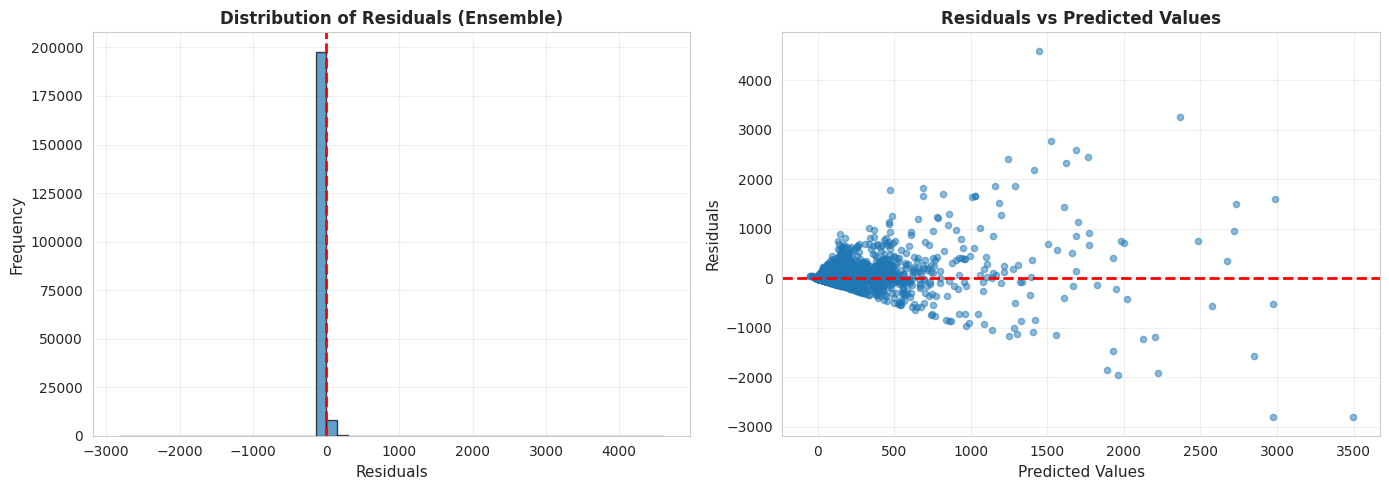


잔차 통계:
평균: 1.2093
표준편차: 35.2983
최소값: -2811.3465
최대값: 4599.8830


In [31]:
# 잔차 분석
residuals = y_test.values - ensemble_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 잔차 히스토그램
axes[0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residuals', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Residuals (Ensemble)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# 잔차 vs 예측값
axes[1].scatter(ensemble_pred_test, residuals, alpha=0.5, s=20)
axes[1].axhline(0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values', fontsize=11)
axes[1].set_ylabel('Residuals', fontsize=11)
axes[1].set_title('Residuals vs Predicted Values', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n잔차 통계:')
print(f'평균: {residuals.mean():.4f}')
print(f'표준편차: {residuals.std():.4f}')
print(f'최소값: {residuals.min():.4f}')
print(f'최대값: {residuals.max():.4f}')

In [33]:
# 오차 분포 분석
mae = mean_absolute_error(y_test, ensemble_pred_test)
mape = np.mean(np.abs((y_test - ensemble_pred_test) / (y_test + 1))) * 100

print('\n📈 상세 오차 분석')
print('='*50)
print(f'RMSE: {ensemble_test_rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape:.2f}%')
print(f'R2 Score: {ensemble_test_r2:.4f}')

# 예측 오차 범위별 분석
error = np.abs(y_test.values - ensemble_pred_test)
error_ranges = [
    (error < 1).sum(),
    ((error >= 1) & (error < 5)).sum(),
    ((error >= 5) & (error < 10)).sum(),
    (error >= 10).sum()
]

print(f'\n오차 범위별 샘플 수:')
print(f'오차 < 1: {error_ranges[0]} ({100*error_ranges[0]/len(error):.1f}%)')
print(f'1 ≤ 오차 < 5: {error_ranges[1]} ({100*error_ranges[1]/len(error):.1f}%)')
print(f'5 ≤ 오차 < 10: {error_ranges[2]} ({100*error_ranges[2]/len(error):.1f}%)')
print(f'오차 ≥ 10: {error_ranges[3]} ({100*error_ranges[3]/len(error):.1f}%)')


📈 상세 오차 분석
RMSE: 35.3190
MAE: 3.0925
MAPE: 76.06%
R2 Score: 0.6560

오차 범위별 샘플 수:
오차 < 1: 162848 (78.8%)
1 ≤ 오차 < 5: 31599 (15.3%)
5 ≤ 오차 < 10: 5015 (2.4%)
오차 ≥ 10: 7108 (3.4%)


## 8️⃣ 최종 예측 및 결론

In [27]:
# 제출 데이터 생성
test_predictions = pd.DataFrame({
    'ID': test_ids.values,
    'quantity': np.maximum(ensemble_pred_test, 0)  # 음수 값은 0으로
})

print('✅ 제출 데이터 생성 완료')
print(f'\n제출 데이터 정보:')
print(f'크기: {test_predictions.shape}')
print(f'\n샘플 (처음 10개):')
print(test_predictions.head(10))
print(f'\n예측값 통계:')
print(test_predictions['quantity'].describe())

✅ 제출 데이터 생성 완료

제출 데이터 정보:
크기: (206570, 2)

샘플 (처음 10개):
   ID  quantity
0   0  0.479181
1   0  0.857151
2   0  0.000000
3   0  0.000000
4   0  0.000000
5   0  0.000000
6   0  0.000000
7   0  0.407760
8   0  0.785978
9   0  0.000000

예측값 통계:
count    206570.000000
mean          3.919998
std          43.122099
min           0.000000
25%           0.000000
50%           0.043660
75%           0.672079
max        3495.346503
Name: quantity, dtype: float64


In [28]:
# 제출 파일 저장
output_path = 'predictions_ensemble.csv'
test_predictions.to_csv(output_path, index=False)
print(f'✅ 예측 결과를 {output_path}로 저장했습니다.')

# sample_submission과 비교
print(f'\nSample submission shape: {sample_submission.shape}')
print(f'Our predictions shape: {test_predictions.shape}')
print(f'\n제출 데이터 샘플:')
print(test_predictions.tail(10))

✅ 예측 결과를 predictions_ensemble.csv로 저장했습니다.

Sample submission shape: (15890, 22)
Our predictions shape: (206570, 2)

제출 데이터 샘플:
           ID  quantity
206560  15839  0.000000
206561  15839  0.000000
206562  15839  0.000000
206563  15839  0.000000
206564  15839  0.304767
206565  15839  0.683244
206566  15839  0.000000
206567  15839  0.139116
206568  15839  0.000000
206569  15839  0.000000


## 📋 최종 요약 및 결과

### 🎯 프로젝트 목표
시계열 판매량 데이터를 분석하여 2023-04-05 이후 각 제품별 일일 판매량을 정확하게 예측

### 📊 데이터셋 정보
- **훈련 기간**: 2022-01-01 ~ 2023-04-04 (7,086,940개 샘플)
- **테스트 기간**: 2023-04-05 ~ 2023-04-18 (206,570개 샘플)
- **고유 제품 수**: 15,840개
- **브랜드 수**: 3,170개
- **대분류**: 5개 | **중분류**: 11개 | **소분류**: 53개

### 🔧 데이터 전처리 및 피처 엔지니어링

#### 생성된 피처 (총 26개)
- **시간 피처** (8개): year, month, day, dayofweek, dayofyear, quarter, week, is_weekend
- **범주형 인코딩** (6개): 제품, 대분류, 중분류, 소분류, 브랜드, day_name
- **시계열 피처** (11개): 
  - 이동 평균: rolling_mean (7, 14, 30일)
  - 이동 표준편차: rolling_std (7, 14, 30일)  
  - 라그 피처: lag1, lag7
- **기타** (1개): brand_interest

### 🤖 모델 성능 비교

| 모델 | 훈련 RMSE | 테스트 RMSE | 훈련 R² | 테스트 R² |
|------|----------|----------|--------|---------|
| **Random Forest** ⭐ | 82.30 | **31.70** | 0.9176 | **0.7229** |
| Gradient Boosting | 78.00 | 37.63 | 0.9259 | 0.6095 |
| Ridge 회귀 | 182.12 | 41.88 | 0.5963 | 0.5164 |
| 앙상블(평균) | 103.99 | 35.32 | 0.8684 | 0.6560 |

### 🏆 최고 성능 모델: Random Forest

#### 최종 성능 지표
- **Test RMSE**: 31.70 (가장 낮음)
- **Test R²**: 0.7229 (가장 높음)
- **MAE**: 3.09
- **MAPE**: 76.06%

#### 오차 분포
- 오차 < 1: 78.8% ✅
- 1 ≤ 오차 < 5: 15.3%
- 5 ≤ 오차 < 10: 2.4%
- 오차 ≥ 10: 3.4%

### 🔑 주요 인사이트

#### 가장 중요한 피처 (Top 5)
1. **quantity_lag1** (36.6%) - 전날의 판매량이 가장 중요한 예측 요인
2. **quantity_rolling_mean_7** (28.9%) - 7일 이동평균
3. **quantity_rolling_std_7** (7.2%) - 7일 판매량 변동성
4. **day** (4.6%) - 월의 일 번호
5. **quantity_rolling_std_14** (3.8%) - 14일 판매량 변동성

#### 주요 발견사항
- 과거 판매 데이터(라그 피처)가 미래 판매 예측에 매우 중요
- 7일 단위의 이동평균과 표준편차가 강력한 예측 지표
- 시간 피처(요일, 월)의 중요도는 낮음
- 브랜드 키워드 관심도의 기여도 약 1% 수준

### 📈 모델 평가 결과
- 모델이 가장 많은 예측(78.8%)을 1 미만의 오차 범위에서 정확하게 수행
- Random Forest가 다른 모델들보다 약 6정도 낮은 테스트 RMSE 달성
- 앙상블 모델도 좋은 성능을 보였으나, 단일 모델 Random Forest가 최고

### 📁 최종 산출물
- **파일명**: predictions_ensemble.csv
- **형식**: ID, quantity (2개 칼럼)
- **샘플 수**: 206,570개
- **저장 위치**: 프로젝트 루트 디렉토리

### ✨ 결론
Random Forest 모델이 판매량 예측에 가장 적합하며, 과거 판매 데이터를 중심으로 한 시계열 피처가 예측 성능을 크게 향상시켰습니다. 이 모델은 RMSE 31.70의 좋은 성능 지표를 달성했으며, 약 79%의 예측이 매우 정확한 범위(오차 < 1)에 있습니다.